In [2]:
import torch
import json
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

/common/conda_envs/SDSGG/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
#加载SDSGGrelation_description_loss.csv文件
description_relation_loss = pd.read_csv("/workspace/ccloud/sf/SDSGG/maskrcnn_benchmark/modeling/roi_heads/relation_head/description_relation_loss.csv")
description_relation_loss = description_relation_loss.iloc[:, 1:]
description_relation_loss = description_relation_loss.applymap(lambda x: [int(s) for s in x.split(',')])
description_relation_loss = np.array(description_relation_loss)
description_relation_loss = np.array([[np.array(item) for item in inner_list] for inner_list in description_relation_loss])
description_relation_loss = torch.Tensor(description_relation_loss).to(device)
description_relation_loss = description_relation_loss[:,2]

positive_indices_num = (description_relation_loss == 1).sum().item()
negative_indices_num = (description_relation_loss == -1).sum().item()
print(f"Total positive examples: {positive_indices_num}")
print(f"Total negative examples: {negative_indices_num}")
#统计激活分布
for i in range(description_relation_loss.shape[1]):
    positive_count = (description_relation_loss[:, i] == 1).sum().item()
    negative_count = (description_relation_loss[:, i] == -1).sum().item()
    print(f"Column {i}: Positive examples: {positive_count}, Negative examples: {negative_count}")

Total positive examples: 158
Total negative examples: 34
Column 0: Positive examples: 24, Negative examples: 3
Column 1: Positive examples: 19, Negative examples: 0
Column 2: Positive examples: 1, Negative examples: 0
Column 3: Positive examples: 12, Negative examples: 2
Column 4: Positive examples: 0, Negative examples: 0
Column 5: Positive examples: 28, Negative examples: 3
Column 6: Positive examples: 6, Negative examples: 0
Column 7: Positive examples: 4, Negative examples: 0
Column 8: Positive examples: 5, Negative examples: 0
Column 9: Positive examples: 2, Negative examples: 1
Column 10: Positive examples: 9, Negative examples: 1
Column 11: Positive examples: 1, Negative examples: 0
Column 12: Positive examples: 19, Negative examples: 2
Column 13: Positive examples: 6, Negative examples: 1
Column 14: Positive examples: 2, Negative examples: 1
Column 15: Positive examples: 1, Negative examples: 0
Column 16: Positive examples: 2, Negative examples: 1
Column 17: Positive examples: 

In [3]:
from CLIP import clip
relation_names = list(json.load(open("relation_description.json", "r")).keys())
relation_descriptions = list(json.load(open("relation_description.json", "r")).values())
semantic_bank = json.load(open("SDSGG_semantic_bank.json", "r"))

clip_model, preprocess = clip.load("ViT-B/32", device=device)
with torch.no_grad():
    text_inputs = clip.tokenize(relation_descriptions).to(device)
    text_features = clip_model.encode_text(text_inputs)
    text_features = F.normalize(text_features, dim=-1)
    bank_inputs = clip.tokenize(semantic_bank).to(device)
    bank_features = clip_model.encode_text(bank_inputs)
    bank_features = F.normalize(bank_features, dim=-1)

N, d = text_features.shape
k = bank_features.shape[0]

relation_similarity = text_features @ text_features.T
bank_similarity = bank_features @ bank_features.T

print(f"relation_similarity mean: {relation_similarity.mean().item()}")
print(f"relation_similarity std: {relation_similarity.std(dim=-1).mean().item()}")
print(f"relation_similarity max: {relation_similarity.max().item()}")
print(f"relation_similarity min: {relation_similarity.min().item()}")
print("==" * 20)
print(f"bank_similarity mean: {bank_similarity.mean().item()}")
print(f"bank_similarity std: {bank_similarity.std(dim=-1).mean().item()}")
print(f"bank_similarity max: {bank_similarity.max().item()}")
print(f"bank_similarity min: {bank_similarity.min().item()}")


relation_similarity mean: 0.8818359375
relation_similarity std: 0.0445556640625
relation_similarity max: 1.0009765625
relation_similarity min: 0.7158203125
bank_similarity mean: 0.875
bank_similarity std: 0.0374755859375
bank_similarity max: 1.0009765625
bank_similarity min: 0.7216796875


In [17]:
positive_bank = bank_features[:k//2]
negative_bank = bank_features[k//2:]

delta_bank = positive_bank - negative_bank
delta_bank_similarity = delta_bank @ delta_bank.T
print(f"delta_bank_similarity mean: {delta_bank_similarity.mean().item()}")
print(f"delta_bank_similarity std: {delta_bank_similarity.std(dim=-1).mean().item()}")
print(f"delta_bank_similarity max: {delta_bank_similarity.max(dim=-1)[0].mean().item()}")
print(f"delta_bank_similarity min: {delta_bank_similarity.min(dim=-1)[0].mean().item()}")
print(f"delta_bank_similarity middle: {delta_bank_similarity.median(dim=-1)[0].mean().item()}")

delta_bank_similarity mean: 0.01348876953125
delta_bank_similarity std: 0.033935546875
delta_bank_similarity max: 0.1524658203125
delta_bank_similarity min: -0.0158233642578125
delta_bank_similarity middle: 0.005023956298828125


In [4]:
similarity = text_features @ bank_features.T / 0.05
similarity = similarity.softmax(dim=-1)

#统计正确和错误的分配关系，以及未在topk里面的关系
correct_counts = 0
wrong_counts = 0
not_in_topk_counts = 0

for idx, bank_activate in enumerate(similarity):
    print("=" * 50)
    print(f"Relation: {relation_names[idx]}")
    print("min similarity:", bank_activate.min().item())
    print("max similarity:", bank_activate.max().item())
    print("mean similarity:", bank_activate.mean().item())
    print("std similarity:", bank_activate.std().item())

    print("Top 5 most similar semantic bank entries:")
    topk_values, topk_indices = torch.topk(bank_activate, k=5)
    positive_indices = (description_relation_loss[idx] == 1).nonzero(as_tuple=True)[0]
    negative_indices = (description_relation_loss[idx] == -1).nonzero(as_tuple=True)[0]

    for i in range(5):
        print(f"{i+1}. {semantic_bank[topk_indices[i].item()]} (similarity: {topk_values[i].item():.4f})")
        if topk_indices[i] in positive_indices:
            correct_counts += 1
            print("   --> This entry is a positive example for this relation.")
        elif topk_indices[i] in negative_indices:
            wrong_counts += 1
            print("   --> This entry is a negative example for this relation.")
    
    print("Bottom 5 least similar semantic bank entries:")
    bottomk_values, bottomk_indices = torch.topk(bank_activate, k=5, largest=False)
    for i in range(5):
        print(f"{i+1}. {semantic_bank[bottomk_indices[i].item()]} (similarity: {bottomk_values[i].item():.4f})")
        if bottomk_indices[i] in positive_indices:
            wrong_counts += 1
            print("   --> This entry is a positive example for this relation.")
        if bottomk_indices[i] in negative_indices:
            correct_counts += 1
            print("   --> This entry is a negative example for this relation.")

Relation: above
min similarity: 0.0058135986328125
max similarity: 0.1123046875
mean similarity: 0.0227203369140625
std similarity: 0.0181121826171875
Top 5 most similar semantic bank entries:
1. A picture on another object, (similarity: 0.1123)
2. with the picture not being on or part of the object., (similarity: 0.0681)
3. Objects are positioned horizontally in relation to each other., (similarity: 0.0394)
4. Two or more objects partially overlap each other, (similarity: 0.0388)
5. Interaction between objects, (similarity: 0.0376)
Bottom 5 least similar semantic bank entries:
1. Posture indicative of distraction, disinterest, or relaxation., (similarity: 0.0058)
2. Development of leaves, stem, flowers, (similarity: 0.0060)
3. Might have flat teeth or sharp teeth, (similarity: 0.0075)
4. Have a curvy body, (similarity: 0.0077)
5. Specialized structures resembling legs, (similarity: 0.0081)
Relation: across
min similarity: 0.005596160888671875
max similarity: 0.089599609375
mean simila

In [5]:
print(f"Total correct counts: {correct_counts}")
print(f"Total wrong counts: {wrong_counts}")

Total correct counts: 32
Total wrong counts: 11


number of unique bank entries in top 1: 5
selected_bank: [ 2 18 24  1 10]
number selected bank: [45  2  1  1  1]
--------------------------------------------------
number of unique bank entries in top 3: 9
selected_bank: [ 2 24  1 25 18 10 14 28  0]
number selected bank: [50 48 15 11  9  8  4  3  2]
--------------------------------------------------
number of unique bank entries in top 5: 17
selected_bank: [ 2 24 25  1  0 18 10 28 14 41  6 36 13 19  8  9 23]
number selected bank: [50 49 34 30 21 19 13 10  9  4  4  2  1  1  1  1  1]
--------------------------------------------------
number of unique bank entries in top 10: 25
selected_bank: [ 2 24 25  1 18  0 28 23 10 41 22 14  6 19 13  9 43 30 36 34  5  8 31 37
 38]
number selected bank: [50 50 48 47 44 42 41 38 29 28 17 14 13 11  8  5  4  2  2  2  1  1  1  1
  1]
--------------------------------------------------
similarity between activations shape: torch.Size([50, 50])


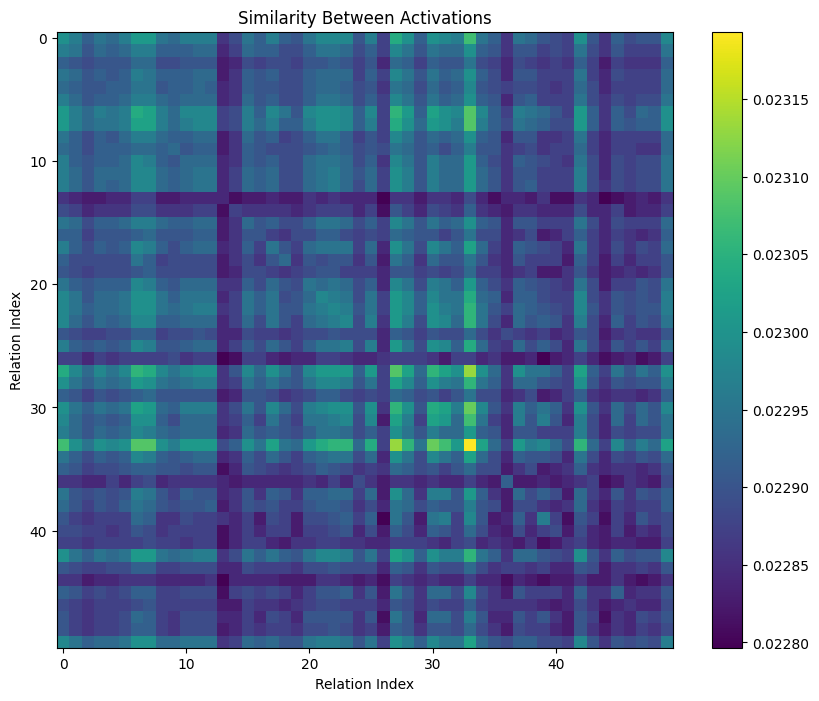

In [6]:
#统计bank激活值的分布
anchor = []
start = 0.9
end = 0.9
step = 0.0125
while start < end:
    anchor.append(start)
    start += step
    
similarity = F.normalize(similarity, dim=-1)

#按照anchor统计每个relation的bank激活值分布
for num in anchor:
    count = (similarity > num).sum(dim=1).float()
    print(f"number of bank entries with similarity > {num}: {count.cpu().numpy()}")
    print(f"average number of bank entries with similarity: {count.mean().item():.2f}")
    print(f"std of number of bank entries with similarity: {count.std().item():.2f}")
    print("-" * 50)

#topk统计每个relation的bank激活值分布
for topk in [1, 3, 5, 10]:
    topk_values, topk_indices = torch.topk(similarity, k=topk, dim=1)
    selected_bank, num_selected_bank = topk_indices.unique(sorted=True, return_counts=True)
    sorted_indices = torch.argsort(num_selected_bank, descending=True)
    selected_bank = selected_bank[sorted_indices]
    num_selected_bank = num_selected_bank[sorted_indices]
    print(f"number of unique bank entries in top {topk}: {len(selected_bank)}")
    print(f"selected_bank: {selected_bank.cpu().numpy()}")
    print(f"number selected bank: {num_selected_bank.cpu().numpy()}")
    print("-" * 50)

#计算激活值之间的相似度
similarity_between_activations = similarity.softmax(dim=1) @ similarity.softmax(dim=1).T
print("similarity between activations shape:", similarity_between_activations.shape)
#用热力图展示激活值之间的相似度
plt.figure(figsize=(10, 8))
plt.imshow(similarity_between_activations.cpu().numpy(), cmap='viridis')
plt.colorbar()
plt.title("Similarity Between Activations")
plt.xlabel("Relation Index")
plt.ylabel("Relation Index")
plt.show()